# Financial Econometrics Project 2025–26

**Marco De Luca**  
**Massil Gouachi**


In [1]:
from typing import Dict, List
from dataclasses import dataclass
import matplotlib.dates as mdates

# Constants and configurations
@dataclass(frozen=True)
class Period:
    name: str
    start: str
    end: str

TICKERS: Dict[str, str] = {
    "Copper": "HG=F", # Copper Futures
    "BCOM": "^BCOM", # Bloomberg Commodity Index
}

PERIODS: List[Period] = [
    Period("2015–2019", "2015-01-01", "2019-12-31"),
    Period("2020–2024", "2020-01-01", "2024-12-31"),
]

DATE_FMT = mdates.DateFormatter("%Y-%m")
DATE_LOC = mdates.AutoDateLocator(minticks=6, maxticks=12)

In [2]:
from pandemicEffectFcts import *
from garchVariationModels import *

## Pandemic Effect on Volatility

This section investigates the impact of the COVID-19 pandemic on asset volatility. Daily price data are collected for the selected assets over the period 2015–2024 and transformed into logarithmic returns and squared log-returns, which serve as a proxy for volatility.

The sample is split into two sub-periods, pre-pandemic (2015–2019) and post-pandemic (2020–2024), allowing for both time-based and cross-asset comparisons. Visual inspections of return dynamics and volatility levels are provided through overlay plots, while summary statistics are used to highlight changes in overall volatility.

Before conducting formal inference, a set of diagnostic checks is performed to verify the assumptions required for heteroskedasticity and autocorrelation robust testing. In particular, stationarity, autocorrelation, and variance stability of squared log-returns are assessed.

Finally, differences in mean volatility across periods and assets are evaluated using HAC/Newey–West two-sample tests. This approach ensures valid statistical inference in the presence of serial dependence and time-varying volatility, which are intrinsic features of financial return data.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


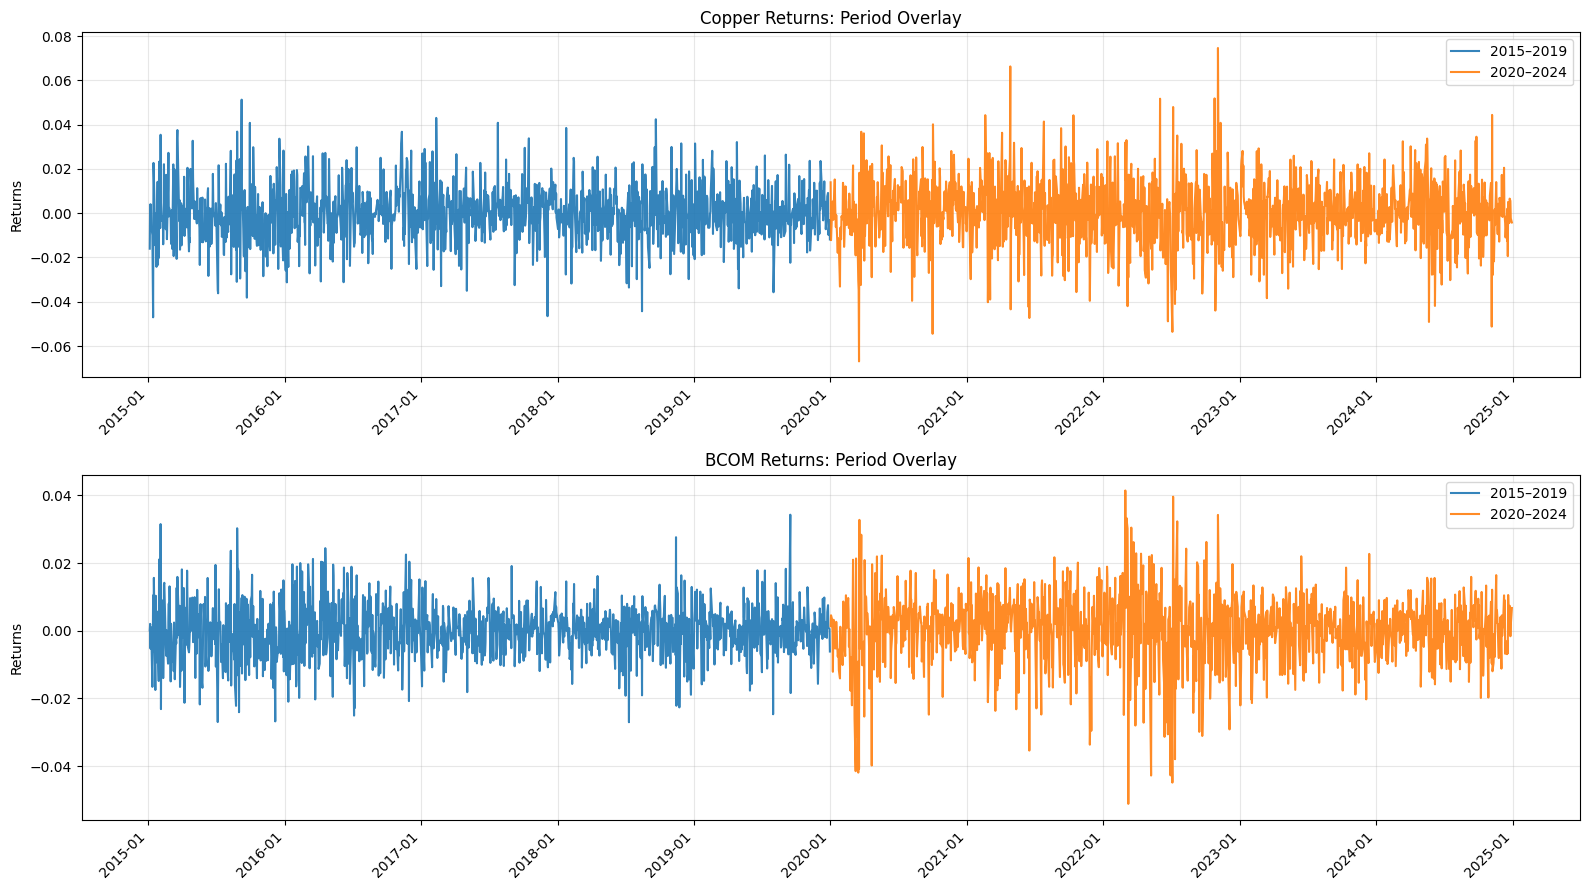


Volatility (Std of SqLogReturn):
 Period  2015–2019  2020–2024
Asset                       
BCOM     0.000112   0.000229
Copper   0.000279   0.000429 

=== Assumption checks for HAC test (squared log-returns) ===
             series     n  Mean_LogRet  Var_LogRet    z_mean0  p_mean0  \
0  Copper 2015–2019  1254 -1.26009e-05 0.000158128 -0.0354851 0.971693   
1  Copper 2020–2024  1258  0.000294222 0.000230167    0.68785 0.491547   
2    BCOM 2015–2019  1257 -0.000198849 6.37175e-05  -0.883207 0.377125   
3    BCOM 2020–2024  1257  0.000159678 0.000106862   0.547649 0.583933   

   ADF_stat        ADF_p   LB_p_lag5  LB_p_lag10  LB_p_lag20      LRV_NW  \
0  -32.4478 2.90936e-231   0.0360114  0.00170912   0.0071235 8.82584e-08   
1   -31.427 4.32641e-217 7.95057e-11 1.27752e-11 6.41571e-09 2.96539e-07   
2  -30.7466 6.77818e-208 3.77476e-15           0           0 2.20852e-08   
3  -13.2462  2.37163e-40           0           0           0 1.21899e-07   

   RollVar_CV_126  ZeroVar_Returns

In [3]:
# Pandemic Effect on Volatility

assets_raw = fetch_assets(TICKERS, start="2015-01-01", end="2024-12-31")

metrics = {asset: compute_metrics_df(df) for asset, df in assets_raw.items()}

metrics_by_asset = {asset: split_by_period(mdf, PERIODS) for asset, mdf in metrics.items()}

plot_overlays(metrics_by_asset, PERIODS)

vol_table = summarize_volatilities(metrics_by_asset)
print("\nVolatility (Std of SqLogReturn):\n", vol_table, "\n")

diag_rows = [
    check_assumptions(f"{asset} {pname}",
                      ret_series=parts[pname]["LogReturn"].to_numpy(),
                      sq_series=parts[pname]["SqLogReturn"].to_numpy())
    for asset, parts in metrics_by_asset.items()
    for pname in parts.keys()
]

assumption_df = pd.DataFrame(diag_rows)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
print("=== Assumption checks for HAC test (squared log-returns) ===")
print(assumption_df[
    ["series","n",
     "Mean_LogRet","Var_LogRet","z_mean0","p_mean0",
     "ADF_stat","ADF_p",
     "LB_p_lag5","LB_p_lag10","LB_p_lag20",
     "LRV_NW","RollVar_CV_126",
     "ZeroVar_Returns","ZeroVar_SqReturns"]
])

# HAC/Newey–West
def series(metrics_by_asset: Dict[str, Dict[str, pd.DataFrame]], asset: str, period: str) -> np.ndarray:
    return metrics_by_asset[asset][period]["SqLogReturn"].to_numpy()

res_rows = []
# TIME effects per asset
for asset in metrics_by_asset:
    res_rows.append(safe_hac(series(metrics_by_asset, asset, "2020–2024"),
                             series(metrics_by_asset, asset, "2015–2019"),
                             f"TIME {asset}: mean(post) - mean(pre)"))

# CROSS-asset within each period
for pname in [p.name for p in PERIODS]:
    a, b = list(metrics_by_asset.keys())
    res_rows.append(safe_hac(series(metrics_by_asset, a, pname),
                             series(metrics_by_asset, b, pname),
                             f"CROSS {pname}: mean({a}) - mean({b})"))

summary_df = pd.DataFrame(res_rows)[
    ["Test","n1","n2","mean_x","mean_y","diff","HAC_SE","z_stat","p_value","lags_x","lags_y"]
]
print("\n=== HAC/Newey–West robust tests on mean volatility (squared log-returns) ===")
print(summary_df)


Assumption checks for HAC test (squared log-returns)
- **series**: Asset and time period considered.
- **n**: Number of observations in the sample.
- **Mean_LogRet**: Sample mean of log-returns, used to check the zero-mean assumption.
- **Var_LogRet**: Sample variance of log-returns.
- **z_mean0**: z-statistic for testing whether the mean log-return is equal to zero.
- **p_mean0**: p-value associated with the zero-mean test on log-returns.
- **ADF_stat**: Augmented Dickey–Fuller test statistic for stationarity of squared log-returns.
- **ADF_p**: p-value of the ADF test; small values indicate stationarity.
- **LB_p_lag5**: Ljung–Box test p-value on squared log-returns at lag 5.
- **LB_p_lag10**: Ljung–Box test p-value on squared log-returns at lag 10.
- **LB_p_lag20**: Ljung–Box test p-value on squared log-returns at lag 20.
- **LRV_NW**: Newey–West long-run variance estimate of squared log-returns.
- **RollVar_CV_126**: Coefficient of variation of the rolling variance (window = 126), measuring volatility instability.
- **ZeroVar_Returns**: Indicator for zero variance in log-returns (degenerate series).
- **ZeroVar_SqReturns**: Indicator for zero variance in squared log-returns.


HAC / Newey–West robust tests on mean volatility
- **Test**: Description of the hypothesis being tested.
- **n1**: Number of observations in sample 1.
- **n2**: Number of observations in sample 2.
- **mean_x**: Mean of squared log-returns in sample 1.
- **mean_y**: Mean of squared log-returns in sample 2.
- **diff**: Difference between the two sample means (mean_x − mean_y).
- **HAC_SE**: Newey–West heteroskedasticity and autocorrelation consistent standard error of the mean difference.
- **z_stat**: HAC-based z-statistic for testing equality of the two means.
- **p_value**: p-value of the HAC z-test; small values indicate statistically significant differences.
- **lags_x**: Number of Newey–West lags used for sample 1.
- **lags_y**: Number of Newey–West lags used for sample 2.

REMARK: when we do the variance test between the two time series pre- and post- covid, we can say that the data at the first date of post is uncorrelated with that at the last date of the pre covid because in the ACF test the legday is small enough.

## T-GARCH(1,1) vs GARCH(1,1)

This section compares the symmetric GARCH(1,1) model with its asymmetric extension, the Threshold GARCH (T-GARCH(1,1)), in order to assess the presence of leverage effects in volatility dynamics. Both models are estimated on de-meaned log-returns for each asset and time period.

The T-GARCH specification allows volatility to respond differently to positive and negative shocks through separate coefficients, while the standard GARCH model imposes symmetry. A likelihood ratio (LR) test is used to formally evaluate whether the asymmetric specification provides a statistically significant improvement over the symmetric benchmark.

In addition to parameter estimates and stationarity checks, residual diagnostics are performed on standardized residuals and their squares using Ljung–Box tests. These diagnostics are used to assess whether the fitted models adequately capture serial dependence and remaining ARCH effects in the data.


In [4]:
# T-GARCH(1,1) vs GARCH(1,1)

tgarch_results = []
for asset, parts in metrics_by_asset.items():
    for period_name in parts.keys():
        eps = get_logreturns(metrics_by_asset, asset, period_name)
        fit_sym = fit_garch11(eps)
        fit_thr = fit_tgarch11(eps)
        lr = lr_test_tgarch_vs_garch(fit_sym, fit_thr)
        diag = tgarch_residual_diagnostics(eps, fit_thr["sigma2"]) if fit_thr.get("success") else {}

        row = {
            "Asset": asset,
            "Period": period_name,
            "nobs": len(eps),
            "GARCH_success": fit_sym["success"],
            "TGARCH_success": fit_thr["success"],
            "omega_sym": fit_sym["params"]["omega"] if fit_sym.get("success") else np.nan,
            "alpha_sym": fit_sym["params"]["alpha"] if fit_sym.get("success") else np.nan,
            "beta_sym": fit_sym["params"]["beta"] if fit_sym.get("success") else np.nan,
            "omega_thr": fit_thr["params"]["omega"] if fit_thr.get("success") else np.nan,
            "alpha_-": fit_thr["params"]["alpha_-"] if fit_thr.get("success") else np.nan,
            "alpha_+": fit_thr["params"]["alpha_+"] if fit_thr.get("success") else np.nan,
            "beta_thr": fit_thr["params"]["beta"] if fit_thr.get("success") else np.nan,
            "stationary_sym": fit_sym.get("stationary", False),
            "stationary_thr": fit_thr.get("stationary", False),
            "LR": lr["LR"],
            "LR_pvalue": lr["pvalue"],
        }
        row.update(diag)
        tgarch_results.append(row)

tgarch_df = pd.DataFrame(tgarch_results)
print("\n=== T-GARCH(1,1) vs GARCH(1,1) results and LR test (H0: α_- = α_+) ===")
print(tgarch_df[
    ["Asset","Period","nobs",
     "omega_sym","alpha_sym","beta_sym",
     "omega_thr","alpha_-","alpha_+","beta_thr",
     "stationary_sym","stationary_thr",
     "LR","LR_pvalue",
     "mean_z","z_stat_mean0","p_mean0",
     "LB_p_resid_lag5","LB_p_resid_lag10","LB_p_resid_lag20",
     "LB_p_sqres_lag5","LB_p_sqres_lag10","LB_p_sqres_lag20"]
])



=== T-GARCH(1,1) vs GARCH(1,1) results and LR test (H0: α_- = α_+) ===
    Asset     Period  nobs   omega_sym  alpha_sym  beta_sym   omega_thr  \
0  Copper  2015–2019  1254 2.01278e-05  0.0459868  0.827762 1.58128e-05   
1  Copper  2020–2024  1258 1.34033e-05  0.0647354  0.877407 2.30167e-05   
2    BCOM  2015–2019  1257   1.181e-06  0.0516554  0.929797 6.37175e-06   
3    BCOM  2020–2024  1257 1.36051e-06  0.0518852  0.933933 1.06862e-05   

   alpha_-  alpha_+  beta_thr  ...  LR_pvalue       mean_z  z_stat_mean0  \
0     0.05     0.05       0.9  ...          1 -0.000697082    -0.0301294   
1     0.05     0.05       0.9  ...          1   0.00104199     0.0456513   
2     0.05     0.05       0.9  ...          1  0.000608053     0.0267959   
3     0.05     0.05       0.9  ...          1 -0.000552389    -0.0250275   

   p_mean0  LB_p_resid_lag5  LB_p_resid_lag10  LB_p_resid_lag20  \
0 0.975964         0.700955         0.0922708          0.138034   
1 0.963588         0.734071          

- **Asset**: Financial asset under analysis.
- **Period**: Time window considered for model estimation.
- **nobs**: Number of observations used in the estimation.
- **omega_sym**: Constant term of the conditional variance in the symmetric GARCH(1,1) model.
- **alpha_sym**: ARCH parameter in the symmetric GARCH model, measuring the impact of past shocks on volatility.
- **beta_sym**: GARCH parameter in the symmetric model, capturing volatility persistence.
- **omega_thr**: Constant term of the conditional variance in the T-GARCH(1,1) model.
- **alpha_-**: T-GARCH coefficient for negative shocks, measuring the impact of negative returns on volatility.
- **alpha_+**: T-GARCH coefficient for positive shocks, measuring the impact of positive returns on volatility.
- **beta_thr**: Persistence parameter in the T-GARCH model.
- **stationary_sym**: Indicator of weak stationarity for the symmetric GARCH model (α + β < 1).
- **stationary_thr**: Indicator of weak stationarity for the T-GARCH model (α_- + α_+ + β < 1).
- **LR**: Likelihood ratio test statistic comparing T-GARCH to GARCH.
- **LR_pvalue**: p-value of the likelihood ratio test for the null hypothesis α_- = α_+ (no leverage effect).
- **mean_z**: Mean of standardized residuals from the T-GARCH model.
- **z_stat_mean0**: z-statistic testing whether the mean of standardized residuals is equal to zero.
- **p_mean0**: p-value of the zero-mean test on standardized residuals.
- **LB_p_resid_lag5**: Ljung–Box test p-value on standardized residuals at lag 5.
- **LB_p_resid_lag10**: Ljung–Box test p-value on standardized residuals at lag 10.
- **LB_p_resid_lag20**: Ljung–Box test p-value on standardized residuals at lag 20.
- **LB_p_sqres_lag5**: Ljung–Box test p-value on squared standardized residuals at lag 5.
- **LB_p_sqres_lag10**: Ljung–Box test p-value on squared standardized residuals at lag 10.
- **LB_p_sqres_lag20**: Ljung–Box test p-value on squared standardized residuals at lag 20.


## EGARCH(1,1): Symmetric vs Asymmetric Specification

This section analyzes volatility dynamics using the Exponential GARCH (EGARCH(1,1)) model, comparing a symmetric specification with an asymmetric version that allows for leverage effects. Unlike standard GARCH-type models, EGARCH models the logarithm of the conditional variance, ensuring positivity and allowing for more flexible asymmetric responses to shocks.

Both specifications are estimated on de-meaned log-returns for each asset and time period. The presence of leverage effects is formally assessed through a likelihood ratio (LR) test of the null hypothesis that the asymmetry parameter λ is equal to zero.

In addition to parameter estimates and stationarity checks, standardized residuals and their squares are examined using Ljung–Box tests to evaluate the adequacy of the model in capturing serial dependence and remaining heteroskedasticity. This analysis allows for a direct comparison between symmetric and asymmetric EGARCH specifications and their ability to model volatility asymmetries.


In [5]:
# EGARCH(1,1) Symmetric vs Asymmetric

egarch_results = []
for asset, parts in metrics_by_asset.items():
    for period_name in parts.keys():
        eps = get_logreturns(metrics_by_asset, asset, period_name)

        fit_sym_eg = fit_egarch11_symmetric(eps)
        fit_asym_eg = fit_egarch11_asym(eps)
        lr_eg = lr_test_egarch_sym_vs_asym(fit_sym_eg, fit_asym_eg)

        diag_keys = [
                            "mean_z","z_stat_mean0","p_mean0",
                            "LB_p_resid_lag5","LB_p_resid_lag10","LB_p_resid_lag20",
                            "LB_p_sqres_lag5","LB_p_sqres_lag10","LB_p_sqres_lag20",
                        ]

        diag_eg = {k: np.nan for k in diag_keys}
        if fit_asym_eg.get("success"):
            diag_eg.update(tgarch_residual_diagnostics(eps, fit_asym_eg["sigma2"]))

        row = {
            "Asset": asset,
            "Period": period_name,
            "nobs": len(eps),
            "EG_sym_success": fit_sym_eg["success"],
            "EG_asym_success": fit_asym_eg["success"],
            "c_sym": fit_sym_eg["params"]["c"] if fit_sym_eg.get("success") else np.nan,
            "alpha_sym": fit_sym_eg["params"]["alpha"] if fit_sym_eg.get("success") else np.nan,
            "gamma_sym": fit_sym_eg["params"]["gamma"] if fit_sym_eg.get("success") else np.nan,
            "c_asym": fit_asym_eg["params"]["c"] if fit_asym_eg.get("success") else np.nan,
            "alpha_asym": fit_asym_eg["params"]["alpha"] if fit_asym_eg.get("success") else np.nan,
            "gamma_asym": fit_asym_eg["params"]["gamma"] if fit_asym_eg.get("success") else np.nan,
            "lambda_asym": fit_asym_eg["params"]["lambda"] if fit_asym_eg.get("success") else np.nan,
            "stationary_sym": fit_sym_eg.get("stationary", False),
            "stationary_asym": fit_asym_eg.get("stationary", False),
            "LR_EG": lr_eg["LR"],
            "LR_EG_pvalue": lr_eg["pvalue"],
        }
        row.update(diag_eg)
        egarch_results.append(row)

egarch_df = pd.DataFrame(egarch_results)
print("\n=== EGARCH(1,1): LR test H0: λ = 0 (no leverage) ===")
print(egarch_df[
    ["Asset","Period","nobs",
     "c_sym","alpha_sym","gamma_sym",
     "c_asym","alpha_asym","gamma_asym","lambda_asym",
     "stationary_sym","stationary_asym",
     "LR_EG","LR_EG_pvalue",
     "mean_z","z_stat_mean0","p_mean0",
     "LB_p_resid_lag5","LB_p_resid_lag10","LB_p_resid_lag20",
     "LB_p_sqres_lag5","LB_p_sqres_lag10","LB_p_sqres_lag20"]
])



=== EGARCH(1,1): LR test H0: λ = 0 (no leverage) ===
    Asset     Period  nobs     c_sym  alpha_sym  gamma_sym    c_asym  \
0  Copper  2015–2019  1254 -0.175599 -0.0196854   0.979999 -0.245296   
1  Copper  2020–2024  1258 -0.654914 -0.0204436     0.9218  -1.24903   
2    BCOM  2015–2019  1257 -0.194249 -0.0340965       0.98 -0.193023   
3    BCOM  2020–2024  1257  -1.21628 -0.0269445   0.867036 -0.187574   

   alpha_asym  gamma_asym  lambda_asym  ...  LR_EG_pvalue       mean_z  \
0  -0.0199328    0.971862     -1.80559  ...      0.017015  0.000818426   
1  -0.0161429    0.850879     -14.6897  ...   8.75966e-14   0.00496025   
2  -0.0330128        0.98     -2.77592  ...             0 -0.000728884   
3  -0.0026734     0.97929      -56.254  ...             0   -0.0013555   

   z_stat_mean0  p_mean0  LB_p_resid_lag5  LB_p_resid_lag10  LB_p_resid_lag20  \
0     0.0288281 0.977002         0.682649         0.0891552          0.128017   
1       0.17594 0.860341         0.828416          0

- **Asset**: Financial asset under analysis.
- **Period**: Time window used for model estimation.
- **nobs**: Number of observations in the sample.
- **c_sym**: Constant term in the symmetric EGARCH(1,1) model (log-variance intercept).
- **alpha_sym**: Shock response coefficient in the symmetric EGARCH model.
- **gamma_sym**: Persistence parameter of the log-variance in the symmetric EGARCH model.
- **c_asym**: Constant term in the asymmetric EGARCH(1,1) model.
- **alpha_asym**: Shock response coefficient in the asymmetric EGARCH model.
- **gamma_asym**: Persistence parameter of the log-variance in the asymmetric EGARCH model.
- **lambda_asym**: Leverage (asymmetry) parameter capturing the differential impact of negative shocks on volatility.
- **stationary_sym**: Indicator of weak stationarity for the symmetric EGARCH model (|γ| < 1).
- **stationary_asym**: Indicator of weak stationarity for the asymmetric EGARCH model (|γ| < 1).
- **LR_EG**: Likelihood ratio test statistic comparing asymmetric and symmetric EGARCH models.
- **LR_EG_pvalue**: p-value of the LR test for the null hypothesis λ = 0 (no leverage effect).
- **mean_z**: Mean of standardized residuals from the asymmetric EGARCH model.
- **z_stat_mean0**: z-statistic testing whether the mean of standardized residuals is equal to zero.
- **p_mean0**: p-value of the zero-mean test on standardized residuals.
- **LB_p_resid_lag5**: Ljung–Box test p-value on standardized residuals at lag 5.
- **LB_p_resid_lag10**: Ljung–Box test p-value on standardized residuals at lag 10.
- **LB_p_resid_lag20**: Ljung–Box test p-value on standardized residuals at lag 20.
- **LB_p_sqres_lag5**: Ljung–Box test p-value on squared standardized residuals at lag 5.
- **LB_p_sqres_lag10**: Ljung–Box test p-value on squared standardized residuals at lag 10.
- **LB_p_sqres_lag20**: Ljung–Box test p-value on squared standardized residuals at lag 20.


## Volatility Modeling and Forecast Evaluation

This section evaluates the out-of-sample volatility forecasting performance of the estimated GARCH-type models. For each asset and time period, model parameters are estimated once and then reused to generate conditional variance series.

Model-implied volatility is compared with a realized volatility proxy based on squared log-returns, smoothed using a rolling window. Volatility series are annualized for interpretability, and graphical comparisons are provided to assess how well each model tracks observed volatility dynamics.

Forecast accuracy is evaluated using multiple complementary metrics, including Mean Squared Error (MSE), the QLIKE loss function, and the correlation between realized and model-implied volatility. These measures allow for a robust comparison of symmetric and asymmetric specifications in terms of their ability to predict volatility.


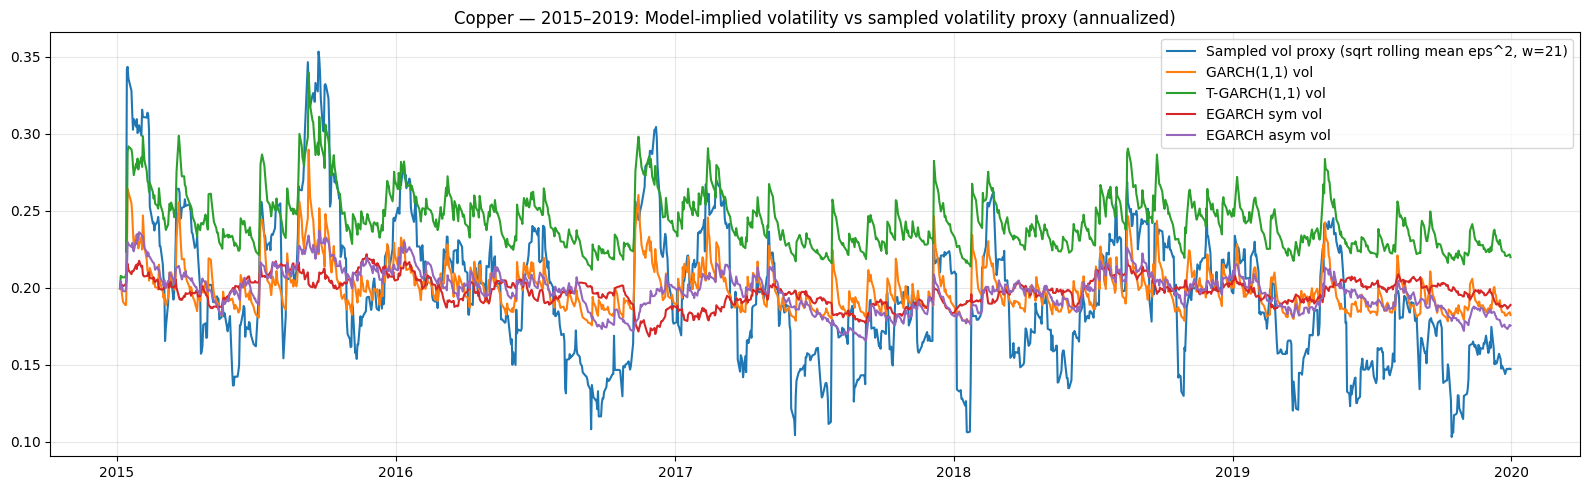

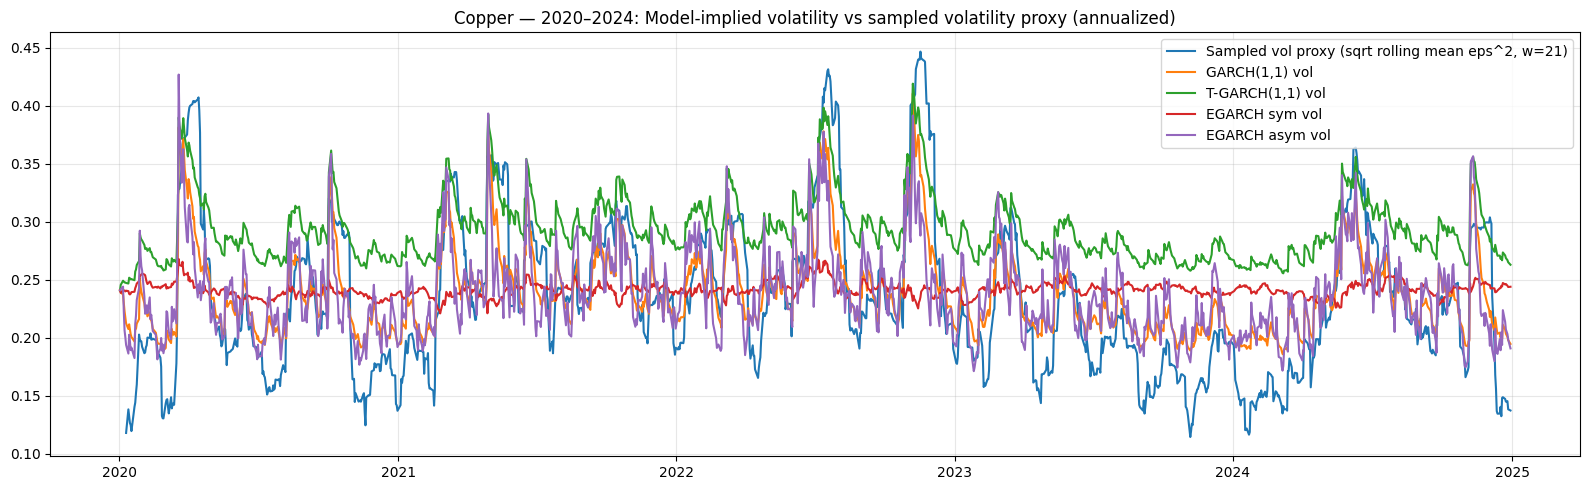

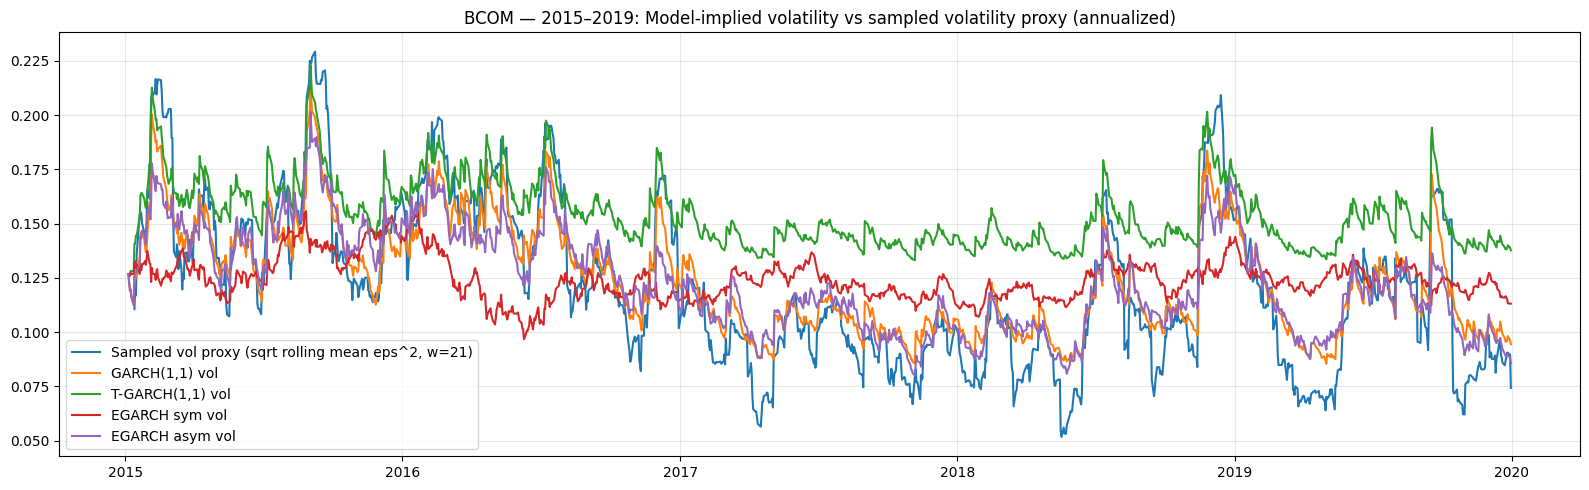

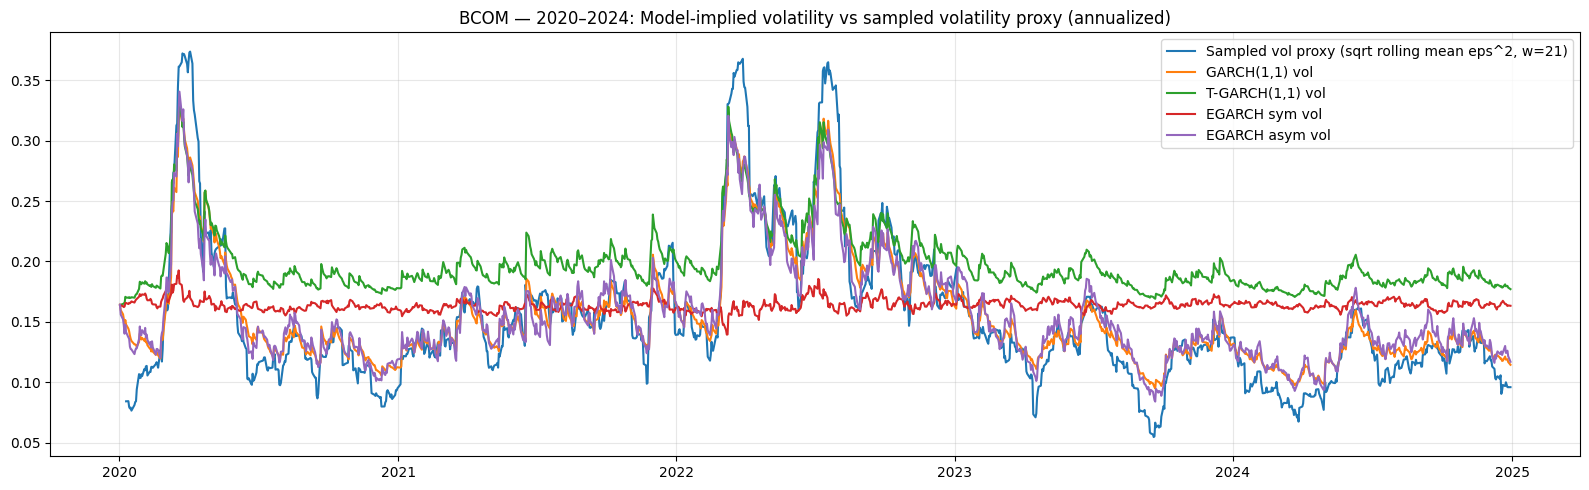


=== Volatility prediction performance (fit once, reuse params) ===
     Asset     Period             Model     n         MSE    QLIKE      corr
11    BCOM  2015–2019  EGARCH(1,1) asym  1257 1.19669e-08 -8.73735  0.215632
8     BCOM  2015–2019        GARCH(1,1)  1257 1.19853e-08 -8.73326  0.213126
10    BCOM  2015–2019   EGARCH(1,1) sym  1257 1.23644e-08 -8.67853  0.130262
9     BCOM  2015–2019      T-GARCH(1,1)  1257 1.30131e-08 -8.63026  0.211831
12    BCOM  2020–2024        GARCH(1,1)  1257 4.78998e-08 -8.30806  0.310396
15    BCOM  2020–2024  EGARCH(1,1) asym  1257 4.79436e-08 -8.29999  0.309987
13    BCOM  2020–2024      T-GARCH(1,1)  1257 5.08562e-08 -8.16353  0.325936
14    BCOM  2020–2024   EGARCH(1,1) sym  1257 5.26911e-08 -8.15161   0.12344
3   Copper  2015–2019  EGARCH(1,1) asym  1254  7.7228e-08 -7.76373 0.0942238
0   Copper  2015–2019        GARCH(1,1)  1254 7.75571e-08 -7.75921 0.0687423
2   Copper  2015–2019   EGARCH(1,1) sym  1254 7.74727e-08 -7.75919 0.0791415
1   Copp

In [6]:
all_rows = []
for asset, parts in metrics_by_asset.items():
    for period_name in parts.keys():
        summ = fit_and_evaluate_vol_models(metrics_by_asset, asset, period_name,
                                           smooth_window=21, annualize=252, plot=True)
        summ.insert(0, "Period", period_name)
        summ.insert(0, "Asset", asset)
        all_rows.append(summ)

perf_df = pd.concat(all_rows, axis=0, ignore_index=True)

print("\n=== Volatility prediction performance (fit once, reuse params) ===")
print(perf_df.sort_values(["Asset","Period","QLIKE"])[["Asset","Period","Model","n","MSE","QLIKE","corr"]])

- **Asset**: Financial asset for which volatility is modeled and evaluated.
- **Period**: Time window over which the model is estimated and evaluated.
- **Model**: Volatility model specification used (GARCH, T-GARCH, EGARCH symmetric or asymmetric).
- **n**: Number of observations used in the evaluation.
- **MSE**: Mean Squared Error between realized volatility (squared log-returns) and model-implied variance; lower values indicate better fit.
- **QLIKE**: Quasi-likelihood loss function commonly used for volatility evaluation; lower (more negative) values indicate superior volatility forecasting performance.
- **corr**: Correlation between realized volatility and model-implied volatility, measuring the strength of linear comovement.
